## Introduction
In this project we developed a content-based music recommendation system 
that suggests similar songs based on the similarity of their audio 
features and lyrical themes. The dataset used contains 28,372 songs with 
23 numerical features.

To measure similarity between songs, we used cosine similarity, since 
this metric is sensitive only to the direction (angle) of vectors rather 
than their absolute magnitude — making it more suitable than Euclidean 
distance for comparing the relative pattern of features between songs.

### The formula to find the cosine similarity between two vectors is:
$$S_C(x, y) = \frac{x \cdot y}{||x|| \times ||y||}$$

#### Reference:
[scikit-learn: Cosine Similarity](https://scikit-learn.org/stable/modules/metrics.html#cosine-similarity)

In [1]:
# setup
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler, MinMaxScaler

## Data Loading
The dataset used, tcc_ceds_music.csv, is from Kaggle and includes 28,372 
songs released between 1950 and 2019. In addition to basic information 
(artist_name, title, genre, release_date), each song contains 16 columns 
of lyrical topic scores (such as dating, violence, romantic) and 6 
extracted audio features (such as danceability, energy, valence). The 
simultaneous presence of these two types of features — content-based 
(lyrical) and audio-based — was the primary reason for selecting this 
dataset to build a multidimensional similarity model.

In [2]:
data = pd.read_csv("tcc_ceds_music.csv")
data.head()

,Unnamed: 0,artist_name,track_name,release_date,genre,lyrics,len,dating,violence,world/life,...,sadness,feelings,danceability,loudness,acousticness,instrumentalness,valence,energy,topic,age
0,0,mukesh,mohabbat bhi jhoothi,1950,pop,hold time feel break feel untrue convince spea...,95,0.000598,0.063746,0.000598,...,0.380299,0.117175,0.357739,0.454119,0.997992,0.901822,0.339448,0.137110,sadness,1.0
1,4,frankie laine,i believe,1950,pop,believe drop rain fall grow believe darkest ni...,51,0.035537,0.096777,0.443435,...,0.001284,0.001284,0.331745,0.647540,0.954819,0.000002,0.325021,0.263240,world/life,1.0
2,6,johnnie ray,cry,1950,pop,sweetheart send letter goodbye secret feel bet...,24,0.002770,0.002770,0.002770,...,0.002770,0.225422,0.456298,0.585288,0.840361,0.000000,0.351814,0.139112,music,1.0
3,10,pérez prado,patricia,1950,pop,kiss lips want stroll charm mambo chacha merin...,54,0.048249,0.001548,0.001548,...,0.225889,0.001548,0.686992,0.744404,0.083935,0.199393,0.775350,0.743736,romantic,1.0
4,12,giorgos papadopoulos,apopse eida oneiro,1950,pop,till darling till matter know till dream live ...,48,0.001350,0.001350,0.417772,...,0.068800,0.001350,0.291671,0.646489,0.975904,0.000246,0.597073,0.394375,romantic,1.0


## Feature Selection
To construct the feature vector of each song, only numerical columns 
that are meaningful in terms of content similarity were selected. The 
`lyrics` column (raw song text) was excluded because it is not directly 
usable for computing cosine similarity. Similarly, the `genre` and 
`topic` columns are categorical and were excluded, since they are 
already numerically represented through the topic scores (such as 
`dating`, `violence`, etc.). Finally, the `len` column (lyric length) 
was excluded as it has no meaningful relationship to a song's mood or 
style.

In [3]:
columns = [
    'dating', 'violence', 'world/life', 'night/time', 
    'shake the audience', 'family/gospel', 'romantic', 
    'communication', 'obscene', 'music', 'movement/places', 
    'light/visual perceptions', 'family/spiritual', 'like/girls', 
    'sadness', 'feelings', 
    'danceability', 'loudness', 'acousticness', 
    'instrumentalness', 'valence', 'energy', 
    'age'
]

In [4]:
features = data[columns].copy()

In [5]:
features.head()

,dating,violence,world/life,night/time,shake the audience,family/gospel,romantic,communication,obscene,music,...,like/girls,sadness,feelings,danceability,loudness,acousticness,instrumentalness,valence,energy,age
0,0.000598,0.063746,0.000598,0.000598,0.000598,0.048857,0.017104,0.263751,0.000598,0.039288,...,0.000598,0.380299,0.117175,0.357739,0.454119,0.997992,0.901822,0.339448,0.137110,1.0
1,0.035537,0.096777,0.443435,0.001284,0.001284,0.027007,0.001284,0.001284,0.001284,0.118034,...,0.001284,0.001284,0.001284,0.331745,0.647540,0.954819,0.000002,0.325021,0.263240,1.0
2,0.002770,0.002770,0.002770,0.002770,0.002770,0.002770,0.158564,0.250668,0.002770,0.323794,...,0.002770,0.002770,0.225422,0.456298,0.585288,0.840361,0.000000,0.351814,0.139112,1.0
3,0.048249,0.001548,0.001548,0.001548,0.021500,0.001548,0.411536,0.001548,0.001548,0.001548,...,0.081132,0.225889,0.001548,0.686992,0.744404,0.083935,0.199393,0.775350,0.743736,1.0
4,0.001350,0.001350,0.417772,0.001350,0.001350,0.001350,0.463430,0.001350,0.001350,0.001350,...,0.001350,0.068800,0.001350,0.291671,0.646489,0.975904,0.000246,0.597073,0.394375,1.0


## Exploratory Data Analysis
To examine the data distribution more closely, the features were 
divided into two separate groups: lyrical features (16 columns of 
topic scores) and audio features (6 columns). This separation allows 
for an independent comparison of the distribution pattern within each 
group in the plots that follow.

In [6]:
lyric_cols = [
    'dating', 'violence', 'world/life', 'night/time', 
    'shake the audience', 'family/gospel', 'romantic', 
    'communication', 'obscene', 'music', 'movement/places', 
    'light/visual perceptions', 'family/spiritual', 'like/girls', 
    'sadness', 'feelings'
]
audio_cols = ['danceability', 'loudness', 'acousticness', 'instrumentalness', 'valence', 'energy']

As shown in the plot, most lyrical topic columns (such as dating, 
shake the audience, family/gospel) have a highly concentrated 
distribution near zero, along with a large number of outliers at the 
upper end of the range. This shows that each song usually has a high 
score on one or two specific topics, rather than uniformly across all 
topics — a phenomenon that makes this category of features sparse. 
This sparsity later became the main reason for the issues observed 
when computing cosine similarity during the analysis.

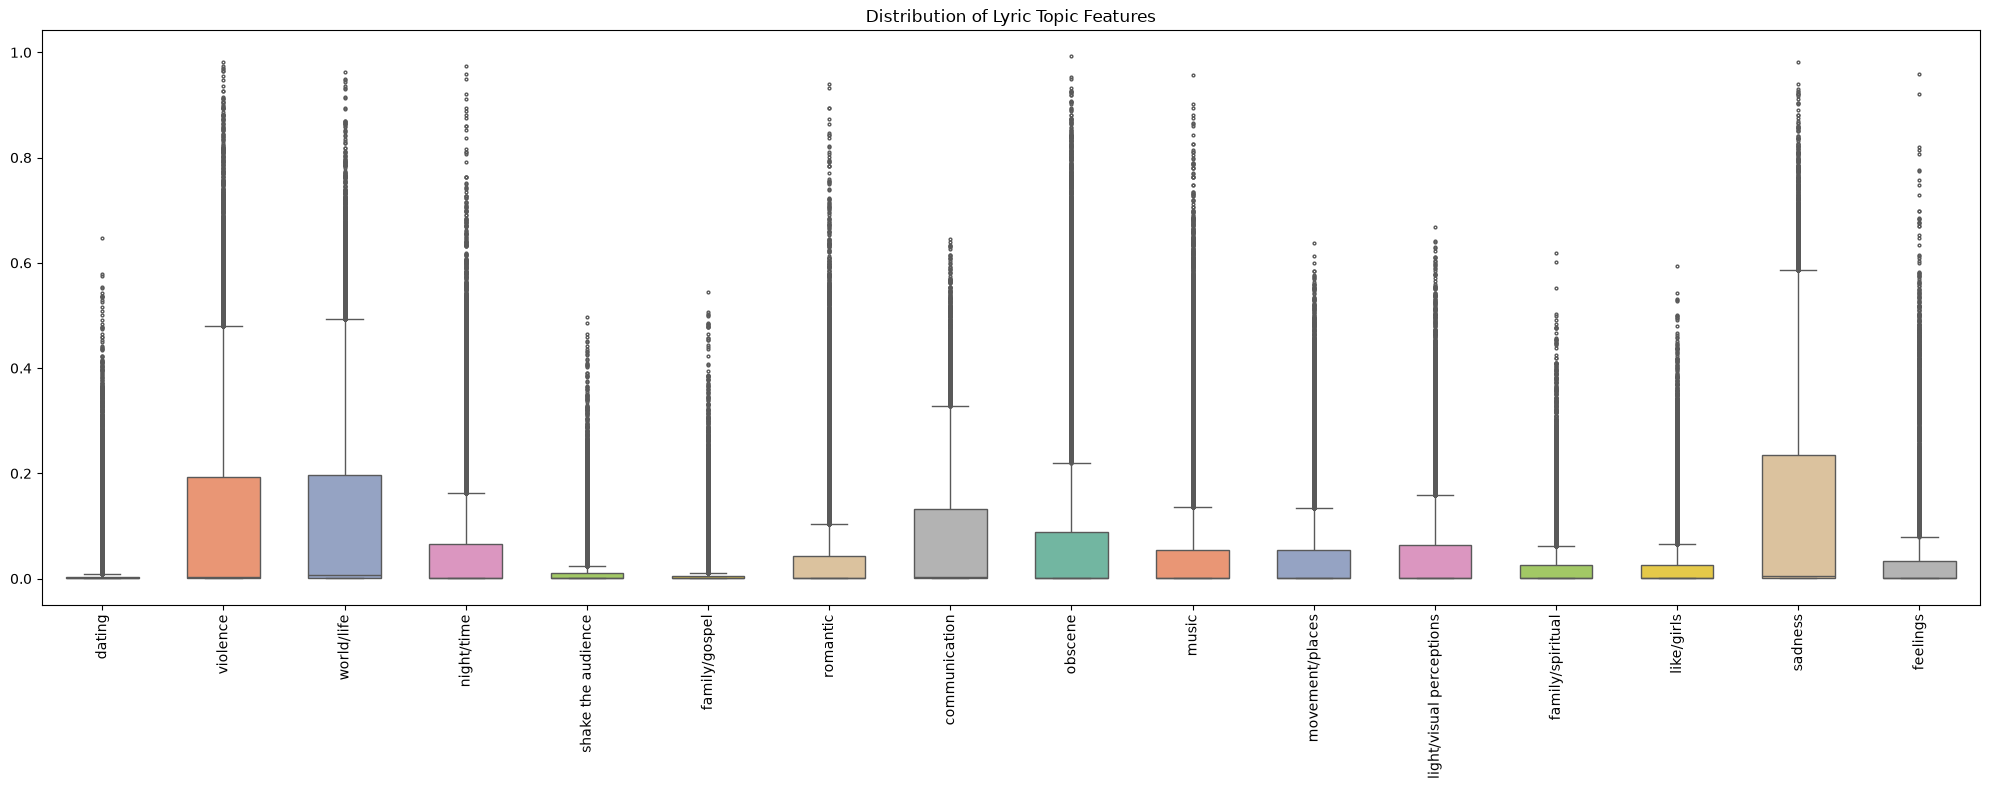

In [7]:
plt.figure(figsize=(20, 8))
sns.boxplot(features[lyric_cols], fliersize=2, linewidth=1, width=0.6, palette="Set2")
plt.xticks(rotation=90)
plt.title("Distribution of Lyric Topic Features")
plt.tight_layout()
plt.show()

Unlike the lyrical topic features, most audio features (particularly 
danceability, valence, energy, and acousticness) exhibit a more 
balanced and wider distribution within the 0 to 1 range, indicating 
that these features vary significantly across different songs. A 
notable exception is the instrumentalness column, which, similar to 
the lyrical features, has a concentrated distribution near zero. This 
is logical, as the majority of songs in this dataset contain vocals 
and are not purely instrumental.

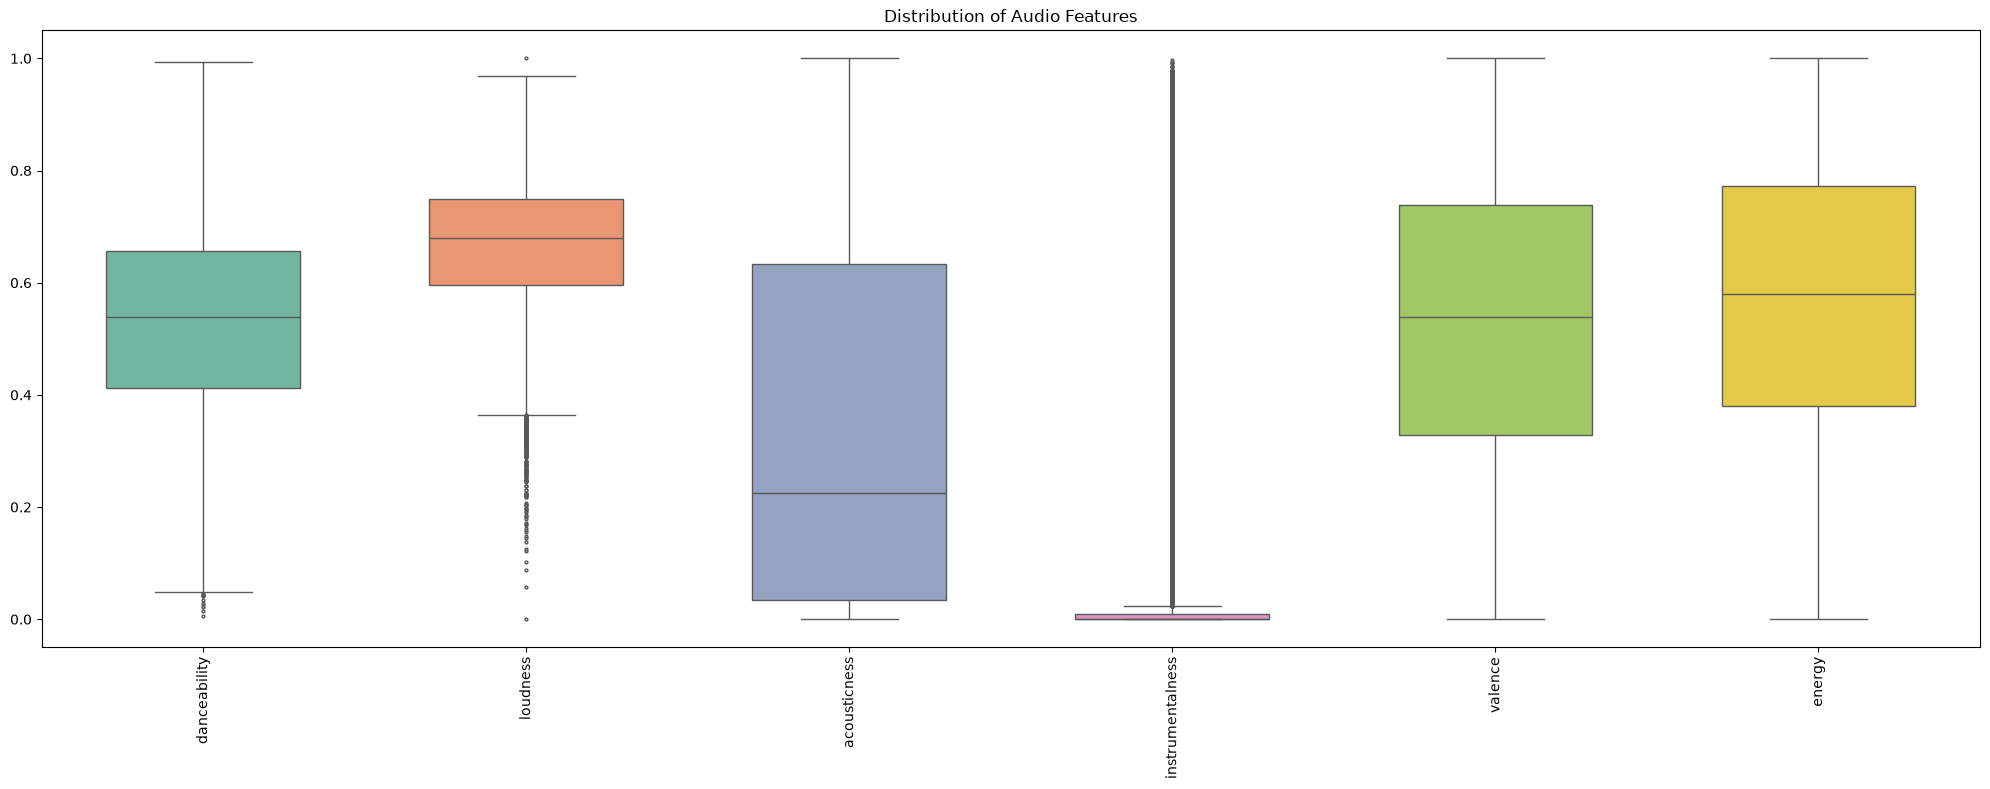

In [8]:
plt.figure(figsize=(20, 8))
sns.boxplot(features[audio_cols], fliersize=2, linewidth=1, width=0.6, palette="Set2")
plt.xticks(rotation=90)
plt.title("Distribution of Audio Features")
plt.tight_layout()
plt.show()

Examining the minimum and maximum values of each column reveals that all features have already been approximately normalized within the 0 to 1 range. However, the actual range of each column is not identical; for instance, the maximum value of the "shake the audience" column is only 0.497, whereas the "obscene" column reaches 0.992. This lack of uniformity indicates that the data was only approximately normalized, rather than precisely and uniformly. Consequently, the explicit application of a uniform scaler was necessary to ensure the exact comparability of all features.

In [9]:
features.describe().loc[["min", "max"]]

,dating,violence,world/life,night/time,shake the audience,family/gospel,romantic,communication,obscene,music,...,like/girls,sadness,feelings,danceability,loudness,acousticness,instrumentalness,valence,energy,age
min,0.000291,0.000284,0.000291,0.000289,0.000284,0.000289,0.000284,0.000291,0.000289,0.000289,...,0.000284,0.000284,0.000289,0.005415,0.0,2.811248e-07,0.000000,0.0,0.0,0.014286
max,0.647706,0.981781,0.962105,0.973684,0.497463,0.545303,0.940789,0.645829,0.992298,0.956938,...,0.594459,0.981424,0.958810,0.993502,1.0,1.000000e+00,0.996964,1.0,1.0,1.000000


## Recommendation Function
The following function returns $N$ similar songs for a given input song based on cosine similarity. A key design consideration is that similarity is computed on-demand and exclusively for that single song (`features[idx:idx+1]` against the entire `features` array), rather than by precomputing a full $N \times N$ matrix. The rationale for this choice is memory constraints: for this dataset of 28,372 songs, constructing the complete similarity matrix would require approximately 6 gigabytes of memory, which is impractical on many systems. In contrast, on-demand computation generates only a $1 \times N$ vector, which has a negligible memory footprint and can be computed in a fraction of a second.

In [10]:
def get_recommendations(song_title, data, features, top_n=10):
    # finding the index of the input song
    idx = data[data['track_name'] == song_title].index
    if len(idx) == 0:  # if the song is not found
        print(f"Song not found: {song_title}")
        return
    idx = idx[0]

    # calculating the similarity just for the input song (on-demand)
    sim_scores = cosine_similarity(features[idx:idx+1], features)[0]
    sim_scores = list(enumerate(sim_scores))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n+1]  # exclude the input song itself (index 0 after sorting)

    song_indices = [i[0] for i in sim_scores]
    scores = [i[1] for i in sim_scores]

    recommendations = data.iloc[song_indices][['track_name', 'artist_name', 'genre']].copy()
    recommendations['similarity'] = scores
    return recommendations

## Experiments
The results of the first experiment, conducted without applying any explicit scaler, indicate that similarity scores for sweater weather fall within a very narrow range (0.979 to 0.985). This compressed range signifies that the model is unable to meaningfully distinguish between "highly similar" and "moderately similar" songs—essentially assigning nearly identical scores to almost all of them. This observation served as the first indication of an underlying issue, which subsequently guided our analysis toward investigating and applying different normalization methods (MinMaxScaler, and ultimately, StandardScaler).

In [11]:
recommendations = get_recommendations("sweater weather", data, features, 10)
print(recommendations[["track_name", "artist_name", "genre", "similarity"]])

                    track_name                        artist_name    genre  \
23069            ocean as well  nahko and medicine for the people   reggae   
22874              bun babylon                           capleton   reggae   
6114               treacherous                       taylor swift      pop   
26921                 migraine                  twenty one pilots     rock   
20371           shoot him down                      alice francis     jazz   
27669              appel local                                 83  hip hop   
5069                   breathe                       blu cantrell      pop   
6882                     knees                         bebe rexha      pop   
22855                  keep on                          the green   reggae   
20402  modern man intermission                         chill bump     jazz   

       similarity  
23069    0.984785  
22874    0.984410  
6114     0.983883  
26921    0.983305  
20371    0.982343  
27669    0.981622  
5

In [12]:
recommendations = get_recommendations("love you like a love song", data, features, 10)
print(recommendations[["track_name", "artist_name", "genre", "similarity"]])

                    track_name                    artist_name    genre  \
28351               basketball                    kurtis blow  hip hop   
6755                 your song                       rita ora      pop   
11826        put you in a song                    keith urban  country   
6328   we are bulletproof pt.2                            bts      pop   
27370              summer days                  a r i z o n a     rock   
20689             bass me baby                        annella     jazz   
22037      u can't sing r song     michael franti & spearhead   reggae   
5404              flow natural              tito "el bambino"      pop   
16258         hot summer night  grace potter & the nocturnals    blues   
15245          into the mystic                     joe cocker    blues   

       similarity  
28351    0.980668  
6755     0.973784  
11826    0.973107  
6328     0.969675  
27370    0.969516  
20689    0.967959  
22037    0.966681  
5404     0.966247  
16258

## MinMaxScaler

In [13]:
scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(features)
features_scaled = pd.DataFrame(features_scaled, columns=columns)

In [14]:
recommendations = get_recommendations("love you like a love song", data, features_scaled, 10)
print(recommendations[["track_name", "artist_name", "genre", "similarity"]])

                                track_name                       artist_name  \
28351                           basketball                       kurtis blow   
11826                    put you in a song                       keith urban   
3821                        american music                    violent femmes   
16338                          black snake  black joe lewis & the honeybears   
6328               we are bulletproof pt.2                               bts   
27370                          summer days                     a r i z o n a   
12403               if i ever get you back                     morgan wallen   
20689                         bass me baby                           annella   
6755                             your song                          rita ora   
22611  always on my mind (feat. sean paul)                          da'ville   

         genre  similarity  
28351  hip hop    0.963279  
11826  country    0.957527  
3821       pop    0.955795  
163

In [15]:
recommendations = get_recommendations("sweater weather", data, features_scaled, 10)
print(recommendations[["track_name", "artist_name", "genre", "similarity"]])

               track_name                        artist_name    genre  \
27669         appel local                                 83  hip hop   
6114          treacherous                       taylor swift      pop   
23069       ocean as well  nahko and medicine for the people   reggae   
20371      shoot him down                      alice francis     jazz   
5069              breathe                       blu cantrell      pop   
22874         bun babylon                           capleton   reggae   
22855             keep on                          the green   reggae   
26921            migraine                  twenty one pilots     rock   
22316  rainbow in the sky                       ziggy marley   reggae   
11868         been around                         cody jinks  country   

       similarity  
27669    0.979406  
6114     0.978390  
23069    0.978152  
20371    0.976023  
5069     0.975571  
22874    0.973773  
22855    0.973543  
26921    0.972056  
22316    0.97181

## PCA
Due to insufficient improvement after MinMaxScaler and the high number 
of features (especially the 16 sparse lyric columns), PCA was applied 
for dimensionality reduction. The cumulative explained variance shows 
that 15 components preserve about 95% of the total variance.

In [16]:
pca = PCA()
pca.fit(features_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

Text(0, 0.5, 'Cumulative Explained Variance')

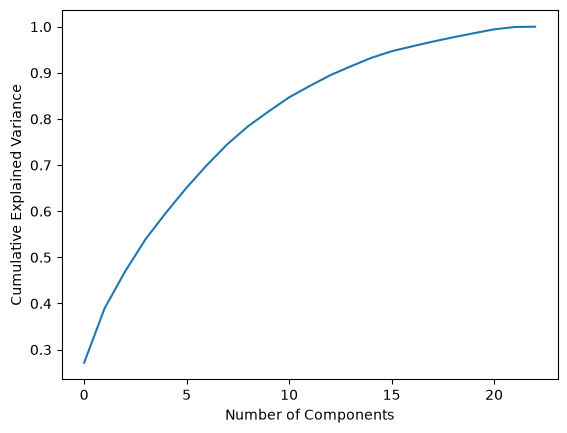

In [17]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
plt.plot(cumulative_variance)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')

In [18]:
pca = PCA(n_components=15)
pca.fit(features_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",15
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD

In [19]:
features_pca = pca.transform(features_scaled)

In [20]:
loadings = pd.Series(pca.components_[0], index=columns).abs().sort_values(ascending=False)
print(loadings.head(10))

acousticness    0.704606
energy          0.488163
age             0.397729
loudness        0.178651
valence         0.162954
obscene         0.115472
violence        0.102050
danceability    0.089074
romantic        0.070203
sadness         0.068414
dtype: float64


Contrary to expectations, the results after PCA did not improve — the 
best score even increased to 0.988, worse than without PCA. Inspecting 
the component loadings above explains why: the first principal component was dominated almost entirely by 
acousticness, energy, and age, while the 16 lyrical-topic features 
(and even loudness, despite being an audio feature) contributed 
comparatively little. Instead of resolving the underlying 
issue, PCA compressed the space into directions shaped mostly by a 
handful of correlated audio dimensions — leaving the core problem 
intact: since MinMax-scaled values are all non-negative, every song's 
feature vector remained confined to a narrow, low-angle region of the 
space, keeping the angle between any two vectors artificially small 
regardless of how different the songs actually are. This finding 
necessitated experimenting with StandardScaler, which centers the data 
around a mean of zero.

In [21]:
recommendations = get_recommendations("love you like a love song", data, features_pca, 10)
print(recommendations[["track_name", "artist_name", "genre", "similarity"]])

                    track_name                 artist_name    genre  \
28351               basketball                 kurtis blow  hip hop   
6328   we are bulletproof pt.2                         bts      pop   
22766   bring it on home to me                        ub40   reggae   
22185        down by the river             morgan heritage   reggae   
19583     so good to feel real                  jamiroquai     jazz   
6755                 your song                    rita ora      pop   
27370              summer days               a r i z o n a     rock   
20689             bass me baby                     annella     jazz   
23026             reggae radio             fortunate youth   reggae   
22037      u can't sing r song  michael franti & spearhead   reggae   

       similarity  
28351    0.988487  
6328     0.942394  
22766    0.941980  
22185    0.932814  
19583    0.930639  
6755     0.927790  
27370    0.920666  
20689    0.919688  
23026    0.917496  
22037    0.915994 

In [22]:
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
features_scaled = pd.DataFrame(features_scaled, columns=columns)

## StandardScaler
By using StandardScaler, the highest similarity score decreased
to 0.831, and the gap between the first and tenth ranks increased
significantly (compared to the near-zero gap in previous experiments).
This result confirms that centering the data around a mean of zero—rather than
dimensionality reduction or normalization to the 0–1 range—was the key factor in 
resolving the model's lack of differentiation.

In [23]:
recommendations = get_recommendations("love you like a love song", data, features_scaled, 10)
print(recommendations[["track_name", "artist_name", "genre", "similarity"]])

                         track_name      artist_name    genre  similarity
12403        if i ever get you back    morgan wallen  country    0.830604
3821                 american music   violent femmes      pop    0.830437
22796                     i'm yours        the green   reggae    0.815646
6393                         studio      schoolboy q      pop    0.811770
12126      i like the sound of that    rascal flatts  country    0.810669
3287                    spring rain  the go-betweens      pop    0.806748
745                          hawaii   the beach boys      pop    0.803573
5271                      rich girl     gwen stefani      pop    0.799483
28351                    basketball      kurtis blow  hip hop    0.796544
22860  oh my goodness ft. big steve     spawnbreezie   reggae    0.790772


In [24]:
recommendations = get_recommendations("sweater weather", data, features_scaled, 10)
print(recommendations[["track_name", "artist_name", "genre", "similarity"]])

            track_name            artist_name    genre  similarity
22855          keep on              the green   reggae    0.801511
16806  outrage! is now  death from above 1979    blues    0.799251
12312     skin & bones         eli young band  country    0.799094
27058             fear             ben rector     rock    0.793539
20405        fraccions                   soen     jazz    0.780552
16810    burning point             gov't mule    blues    0.780498
27669      appel local                     83  hip hop    0.780182
23035         anointed                  bugle   reggae    0.777095
5069           breathe           blu cantrell      pop    0.775570
6703          starving       hailee steinfeld      pop    0.770505


Comparing the range of scores between the two experimental songs shows 
that "Sweater Weather" falls within the range of 0.77 to 0.80, while 
"Love You Like a Love Song" falls within 0.79 to 0.83. Compared to the 
earlier experiments — where the ranges were completely overlapping and 
inseparable — these two ranges now show a more meaningful separation 
from each other. However, some overlap still remains, which indicates 
that the model, although significantly improved, still cannot fully 
place two thematically different songs into two completely separate 
ranges.

While the top-10 recommendations for sweater weather before scaling were compressed into a narrow band (0.979–0.985), the full distribution across all songs shows the deeper issue: most songs skewed toward high similarity regardless of actual content, making it hard to distinguish a great match from an okay match. After StandardScaler, the distribution shifts toward lower similarity for most songs, with only a smaller subset showing meaningfully elevated scores.

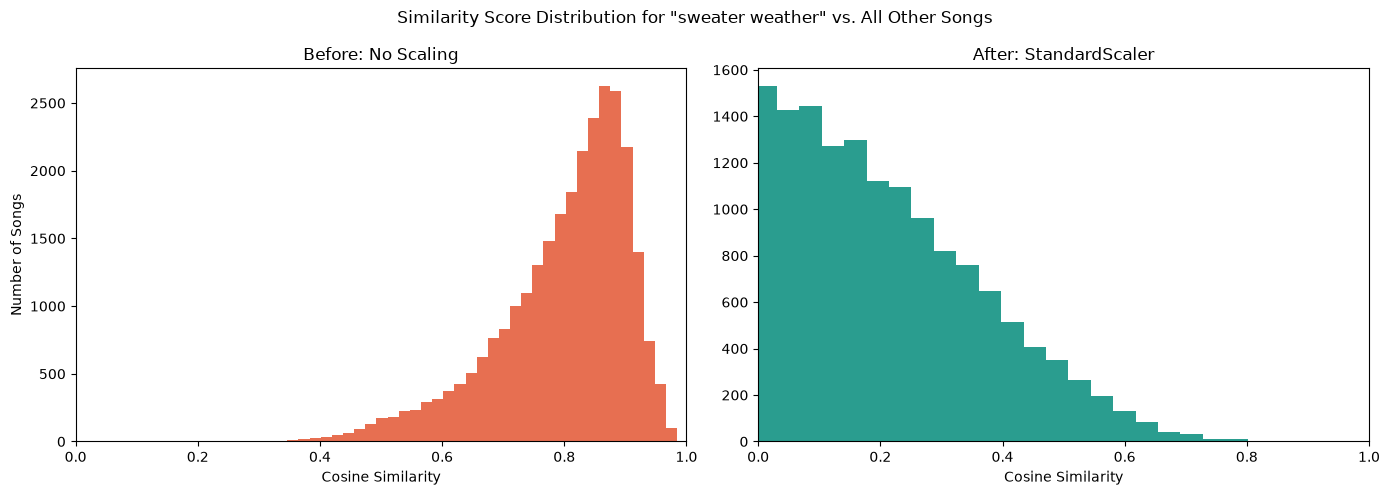

In [25]:
sample_song = "sweater weather"
idx = data[data['track_name'] == sample_song].index[0]

sim_before = cosine_similarity(features[idx:idx+1], features)[0]
sim_before = np.delete(sim_before, idx)  # excluding the song itself

sim_after = cosine_similarity(features_scaled[idx:idx+1], features_scaled)[0]
sim_after = np.delete(sim_after, idx)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(sim_before, bins=40, color="#e76f51")
axes[0].set_xlim(0, 1)
axes[0].set_title("Before: No Scaling")
axes[0].set_xlabel("Cosine Similarity")
axes[0].set_ylabel("Number of Songs")

axes[1].hist(sim_after, bins=40, color="#2a9d8f")
axes[1].set_xlim(0, 1)
axes[1].set_title("After: StandardScaler")
axes[1].set_xlabel("Cosine Similarity")

plt.suptitle(f'Similarity Score Distribution for "{sample_song}" vs. All Other Songs')
plt.tight_layout()
plt.savefig("similarity_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

## Conclusion
Ultimately, the model developed in this project is a content-based recommendation system
that suggests similar songs based on audio features and lyrical topics, utilizing cosine similarity and StandardScaler.
The most significant finding of this project was that the type of data
normalization (StandardScaler versus MinMaxScaler) played a far more critical
role in improving the model's discriminative power than dimensionality reduction (PCA).
However, some overlap between thematically different songs is still observed;
addressing this issue through separate weighting of audio and lyrical features could
be a promising direction for the future development of this project.